In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import(
    Dense, Conv2D, MaxPooling2D, 
    Input, RandomFlip, RandomRotation,
    RandomZoom, RandomTranslation, Flatten
    )  
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras.datasets import cifar10

2026-06-19 17:03:37.899611: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 17:03:37.942501: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-19 17:03:39.227278: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [4]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [5]:
# Data Augmentation
dat_augmentation = Sequential([
    RandomFlip("horizontal"), # Espelhamento
    RandomRotation(0.03), # 0 a 8% de rotação
    RandomZoom(0.04), # Aplicar zom na faixa de 0 a 10%
    RandomTranslation(0.02,0.02), # Desloca até 10% na horizontal e 10% na vertical
], name='data_augmentation')

I0000 00:00:1781899422.015175   17892 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
X_train[2:3].shape

(1, 32, 32, 3)

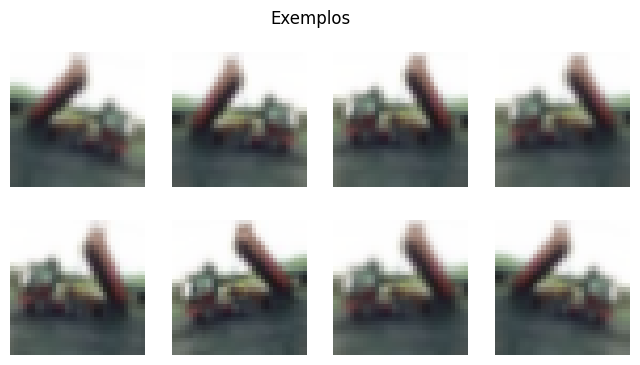

In [7]:
# Visualização dos dados
plt.figure(figsize=(8,4))

sample = X_train[2:3]
sample

for i in range(8):
    aug = dat_augmentation(sample, training= True)
    plt.subplot(2,4, i+ 1)
    plt.imshow(aug[0].numpy())
    plt.axis("off")

plt.suptitle("Exemplos")
plt.show()


In [8]:
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,3,activation='relu', padding="same"),
    MaxPooling2D(),
    Conv2D(64,3,activation='relu', padding="same"),
    MaxPooling2D(),
    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10,activation='softmax')
])


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,292,314 (8.74 MB)

 Trainable params: 2,292,314 (8.74 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    min_delta=0.01
)

In [11]:
history = model.fit(
    X_train,y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=512,
    callbacks=[early_stop]
)

Epoch 1/100


2026-06-19 17:03:46.208573: I external/local_xla/xla/service/service.cc:163] XLA service 0xcd2c2b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-19 17:03:46.208717: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-19 17:03:46.249948: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-19 17:03:46.633030: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-19 17:03:46.671501: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:03:46.671648: I extern

 3/88 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.0951 - loss: 2.3059  

I0000 00:00:1781899437.425356   18002 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1502 - loss: 2.2100

2026-06-19 17:03:59.135559: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:03:59.135672: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:03:59.135694: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:03:59.136046: I external/l

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.1507 - loss: 2.2089

2026-06-19 17:04:10.045683: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:04:10.045749: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:04:10.878407: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_77', 12 bytes spill stores, 12 bytes spill loads

2026-06-19 17:04:10.935358: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.1512 - loss: 2.2078 - val_accuracy: 0.2842 - val_loss: 1.9183
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3067 - loss: 1.8540 - val_accuracy: 0.4182 - val_loss: 1.5901
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4298 - loss: 1.5483 - val_accuracy: 0.4950 - val_loss: 1.3923
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5112 - loss: 1.3400 - val_accuracy: 0.5262 - val_loss: 1.2931
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5555 - loss: 1.2281 - val_accuracy: 0.5804 - val_loss: 1.1716
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5922 - loss: 1.1415 - val_accuracy: 0.5964 - val_loss: 1.1275
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6164 - loss: 1.0766 - val_accuracy: 0.6270 - val_loss: 1.0591
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6376 - loss: 1.0156 - val_accuracy: 0.6328 - val

In [12]:
preds_prob = model.predict(X_test)
preds_prob

2026-06-19 17:04:56.432559: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:04:56.432615: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-19 17:04:57.982389: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 8 bytes spill stores, 8 bytes spill loads

2026-06-19 17:04:58.191684: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2026-06-19 17:05:01.953280: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 8 bytes spill stores, 8 bytes spill loads

2026-06-19 17:05:02.025650: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_72', 8 bytes spill stores, 8 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


array([[1.1314784e-02, 8.7518175e-04, 2.6775632e-02, ..., 1.1232299e-02,
        1.9853161e-01, 9.6828835e-03],
       [8.3745252e-03, 8.6543119e-01, 9.1645074e-05, ..., 2.0200977e-04,
        1.0709313e-01, 1.8363282e-02],
       [7.9806197e-01, 5.8207377e-03, 9.8204771e-03, ..., 1.6821795e-03,
        1.6826256e-01, 6.2903645e-03],
       ...,
       [1.6775507e-03, 1.2240598e-05, 4.6058860e-01, ..., 4.6180323e-02,
        5.3253630e-03, 1.3497281e-04],
       [3.2258901e-01, 1.3985159e-01, 1.8761960e-01, ..., 1.2539449e-02,
        5.7259472e-03, 6.5649059e-03],
       [6.0999409e-06, 1.5043201e-05, 1.1005406e-04, ..., 9.4839793e-01,
        7.8483298e-10, 9.0312369e-06]], dtype=float32)

In [13]:
preds = np.argmax(preds_prob, axis=1)
preds

array([5, 1, 0, ..., 2, 0, 7])

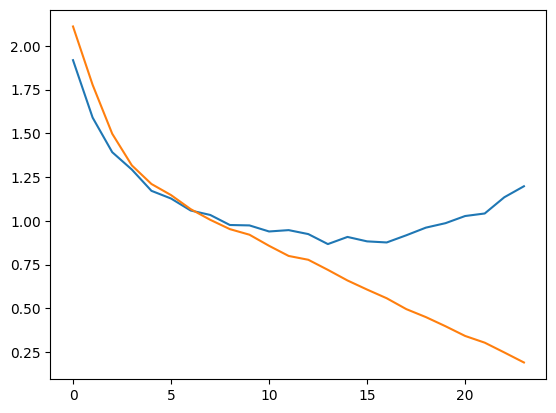

In [14]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['loss'])

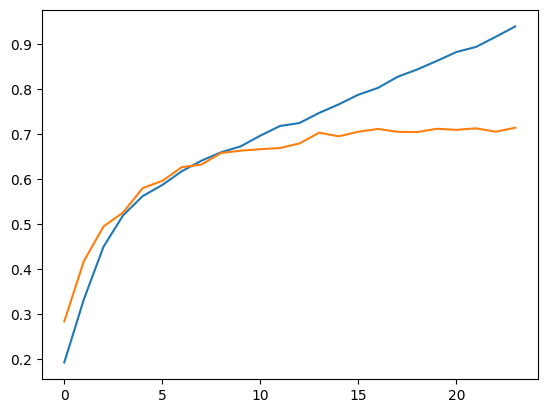

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [16]:
print(classification_report(preds,y_test))

              precision    recall  f1-score   support

           0       0.78      0.69      0.73      1116
           1       0.76      0.84      0.80       900
           2       0.62      0.52      0.57      1183
           3       0.52      0.51      0.51      1015
           4       0.62      0.64      0.63       972
           5       0.60      0.61      0.60       984
           6       0.73      0.81      0.77       904
           7       0.74      0.77      0.76       960
           8       0.79      0.82      0.81       960
           9       0.78      0.77      0.77      1006

    accuracy                           0.69     10000
   macro avg       0.69      0.70      0.69     10000
weighted avg       0.69      0.69      0.69     10000

